# 06 — Engagement vs Attrition (Contextual Only)
**Note:** this notebook does not try to predict attrition. It only checks whether the Engagement Index and Burnout Risk line up with who actually left, as a sanity check on the metrics built in notebooks 02 and 03.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
df = pd.read_csv('../data/processed/full_scored.csv')
df['Attrition'].value_counts()

Attrition
0    1233
1     237
Name: count, dtype: int64

## Engagement Index: stayed vs left

In [2]:
df.groupby('Attrition')[['EngagementIndex']].mean()

,EngagementIndex
Attrition,
0,0.550394
1,0.459148


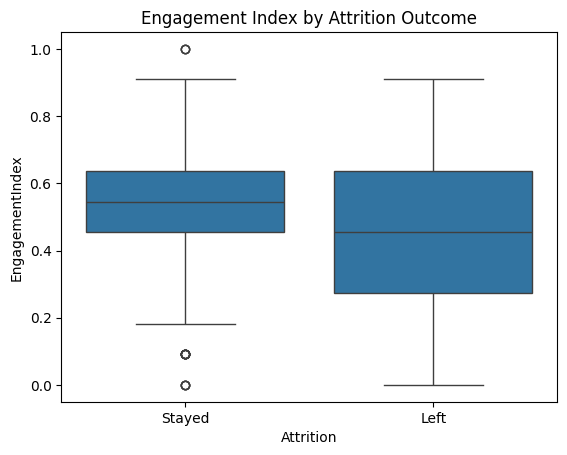

In [3]:
sns.boxplot(data=df, x='Attrition', y='EngagementIndex')
plt.xticks([0, 1], ['Stayed', 'Left'])
plt.title('Engagement Index by Attrition Outcome')
plt.show()

## Burnout risk: stayed vs left

In [4]:
pd.crosstab(df['Attrition'], df['BurnoutRisk'], normalize='index').round(2)

BurnoutRisk,High,Low,Medium
Attrition,,,
0,0.10,0.07,0.83
1,0.29,0.04,0.67


## Combined view: engagement tier x attrition rate
The attrition *rate* (fraction who left) within each engagement tier — this is the key diagnostic chart for the research paper.

In [5]:
attrition_rate = df.groupby('EngagementTier')['Attrition'].mean().round(3) * 100
attrition_rate = attrition_rate.reindex(['Low', 'Medium', 'High'])
attrition_rate

EngagementTier
Low       34.1
Medium    14.8
High      10.2
Name: Attrition, dtype: float64

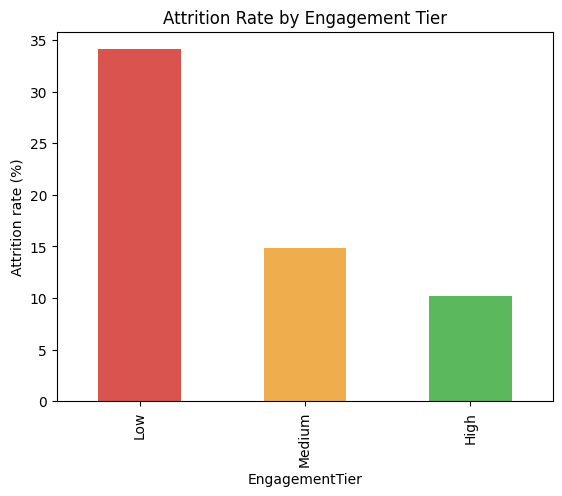

In [6]:
attrition_rate.plot(kind='bar', color=['#d9534f', '#f0ad4e', '#5cb85c'])
plt.ylabel('Attrition rate (%)')
plt.title('Attrition Rate by Engagement Tier')
plt.show()

## Takeaway cell
Fill this in once the notebook has run — summarize in 2-3 sentences whether low engagement / high burnout risk groups show a higher attrition rate, for use in the research paper and executive summary.

In [7]:
# Example:
# print(f"Low-engagement employees left at {attrition_rate['Low']:.1f}%, "
#       f"compared to {attrition_rate['High']:.1f}% for high-engagement employees.")